## Priority Labels Cleaning
-   Merging priorities where the agreement is 2/3
-   Manually labeling emails where the agreement is 1/3
-   The three priority classes (High / Medium / Low) are retained

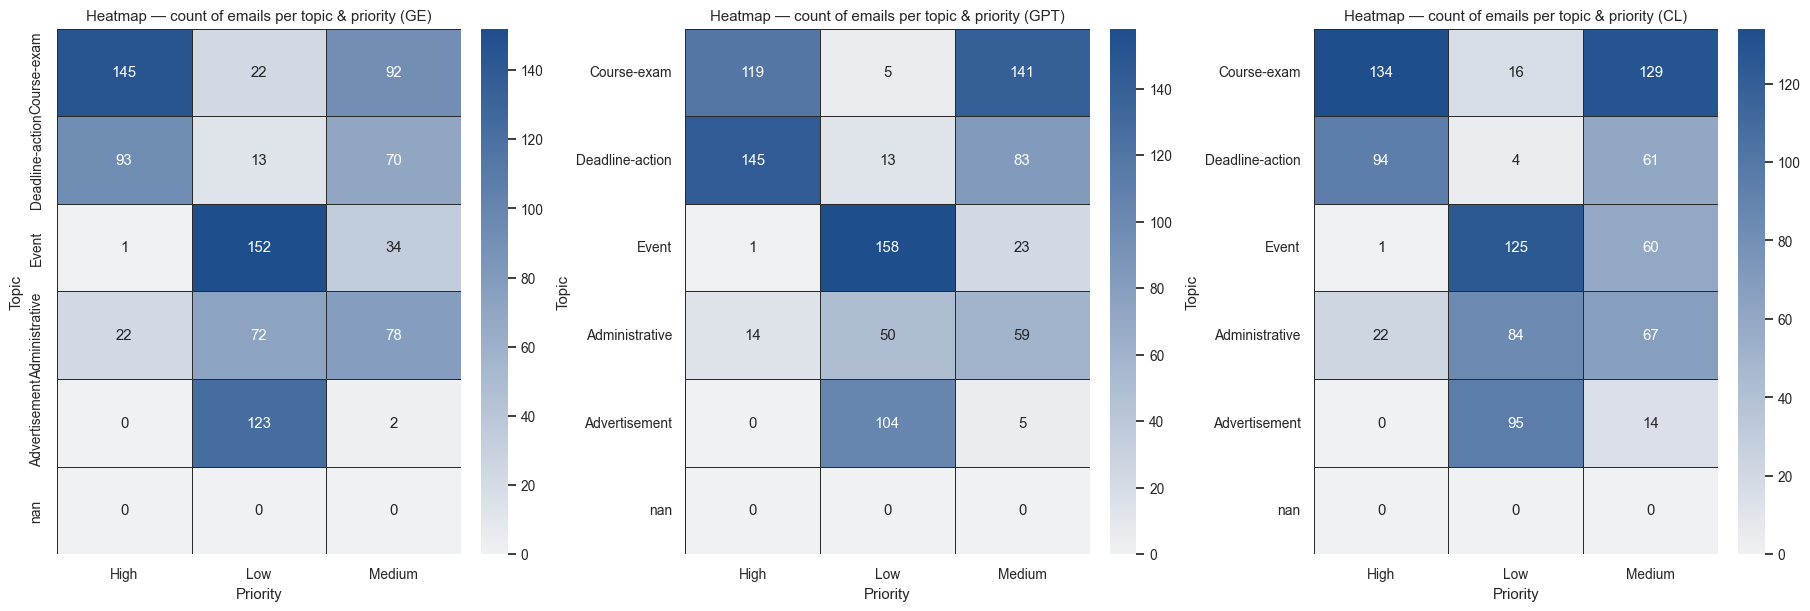

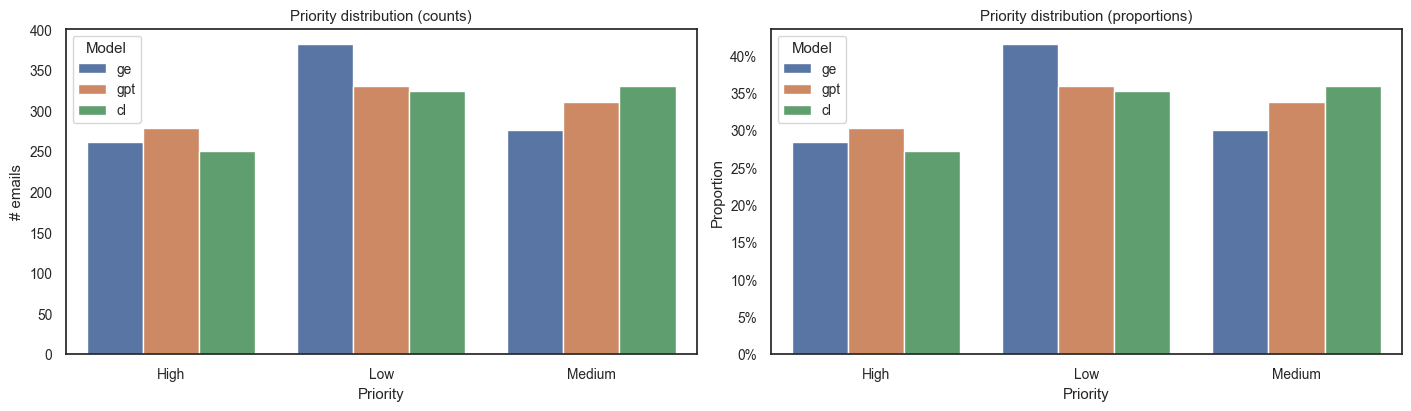

priority_label,High,Low,Medium
model,,,
ge,261,382,276
gpt,279,330,311
cl,251,324,331


Chi-square test (model × priority): chi2=12.351, dof=4, p=0.0149


In [5]:
# === APPENDIX (optional, beyond report scope): topic x priority heatmaps, per-model priority bars, and chi-square test ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- Load ---
df = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")

# --- Reshape to (model, topic_label, priority_label) ---
model_specs = {
    "ge": ("ge_topic_label", "ge_priority_label"),
    "gpt": ("gpt_topic_label", "gpt_priority_label"),
    "cl": ("cl_topic_label", "cl_priority_label"),
}

long_parts = []
for model, (topic_col, prio_col) in model_specs.items():
    part = df[["id", topic_col, prio_col]].copy()
    part = part.rename(columns={topic_col: "topic_label", prio_col: "priority_label"})
    part["model"] = model
    long_parts.append(part)

long_df = pd.concat(long_parts, ignore_index=True)

# Normalize label text a bit (in case of stray whitespace/casing)
long_df["topic_label"] = long_df["topic_label"].astype(str).str.strip()
long_df["priority_label"] = long_df["priority_label"].astype(str).str.strip()

# Orders (match your example: columns High, Low, Medium; we’ll still keep a stable categorical order)
priority_order = ["High", "Low", "Medium"]

# If some labels are missing, keep only what exists (prevents empty columns errors)
present_prios = [p for p in priority_order if p in set(long_df["priority_label"]) ]

# Choose a stable topic order by overall frequency (across all models)
topic_order = (
    long_df["topic_label"].value_counts()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# --- Heatmaps: count of emails per topic & priority, for each model ---

def plot_heatmap_for_model(model_name: str, ax: plt.Axes):
    sub = long_df[long_df["model"] == model_name]

    pivot = (
        sub.pivot_table(
            index="topic_label",
            columns="priority_label",
            values="id",
            aggfunc="count",
            fill_value=0,
        )
        .reindex(index=topic_order)
        .reindex(columns=present_prios)
    )

    # reindex can introduce NaNs for missing topics/priorities; fill then cast for fmt="d"
    pivot = pivot.fillna(0).astype(int)

    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap=sns.light_palette("#1f4e8c", as_cmap=True),
        linewidths=0.5,
        linecolor="#2a2a2a",
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Heatmap — count of emails per topic & priority ({model_name.upper()})")
    ax.set_xlabel("Priority")
    ax.set_ylabel("Topic")


sns.set_theme(style="white", font_scale=0.9)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, model in zip(axes, ["ge", "gpt", "cl"]):
    plot_heatmap_for_model(model, ax)
plt.show()

# --- Compare distribution of priority labels between CL, GPT, and GE ---

# Counts per model
prio_counts = (
    long_df.groupby(["model", "priority_label"]) ["id"].count().rename("count").reset_index()
)

# Ensure consistent ordering
prio_counts["priority_label"] = pd.Categorical(prio_counts["priority_label"], categories=present_prios, ordered=True)
prio_counts["model"] = pd.Categorical(prio_counts["model"], categories=["ge", "gpt", "cl"], ordered=True)
prio_counts = prio_counts.sort_values(["model", "priority_label"])

# Proportions per model
prio_totals = prio_counts.groupby("model")["count"].transform("sum")
prio_counts["prop"] = prio_counts["count"] / prio_totals

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

sns.barplot(
    data=prio_counts,
    x="priority_label",
    y="count",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("Priority distribution (counts)")
axes[0].set_xlabel("Priority")
axes[0].set_ylabel("# emails")

sns.barplot(
    data=prio_counts,
    x="priority_label",
    y="prop",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("Priority distribution (proportions)")
axes[1].set_xlabel("Priority")
axes[1].set_ylabel("Proportion")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0%}"))

for ax in axes:
    ax.legend(title="Model")

plt.show()

# Optional: simple statistical test (chi-square) on model × priority contingency
contingency = (
    long_df.pivot_table(
        index="model",
        columns="priority_label",
        values="id",
        aggfunc="count",
        fill_value=0,
    )
    .reindex(index=["ge", "gpt", "cl"])
    .reindex(columns=present_prios)
)

try:
    from scipy.stats import chi2_contingency

    chi2, p, dof, expected = chi2_contingency(contingency.values)
    display(contingency)
    print(f"Chi-square test (model × priority): chi2={chi2:.3f}, dof={dof}, p={p:.3g}")
except Exception as e:
    display(contingency)
    print("SciPy not available (or test failed). Showing contingency table only.")
    print(f"Details: {type(e).__name__}: {e}")


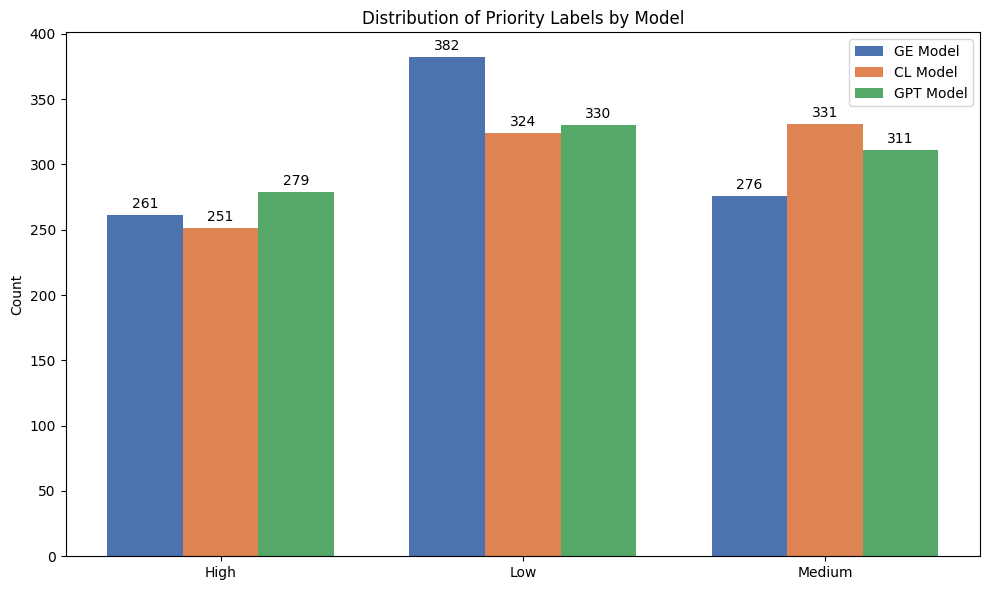

In [1]:
# === APPENDIX (optional, beyond report scope): static snapshot of the per-model priority distribution chart ===
import matplotlib.pyplot as plt
import numpy as np

# Define the categories (priority labels)
categories = ['High', 'Low', 'Medium']

# Define the counts for each model based on the provided table image
ge_counts = [261, 382, 276]
cl_counts = [251, 324, 331]
gpt_counts = [279, 330, 311]

# Set up the x locations for the groups
x = np.arange(len(categories))

# Set the width of the bars
width = 0.25

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars for each model, shifting their x positions to group them
# Keeping the same color scheme as the previous chart for consistency
rects1 = ax.bar(x - width, ge_counts, width, label='GE Model', color='#4c72b0')
rects2 = ax.bar(x, cl_counts, width, label='CL Model', color='#dd8452')
rects3 = ax.bar(x + width, gpt_counts, width, label='GPT Model', color='#55a868')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Count')
ax.set_title('Distribution of Priority Labels by Model')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add value labels on top of the bars for exact numbers
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Adjust layout to prevent clipping
fig.tight_layout()

# Display the plot
plt.show()

### Creating 3 label dataset and merging the unique piority labels.

In [ ]:
# === APPENDIX (optional, beyond report scope): duplicate of the low-agreement viewer below (cell runs only after the 3-label file exists) ===
import pandas as pd

path = "../data/annotation/annotation_dataset_clean_3label.csv"
df = pd.read_csv(path)

cols = [
    "id",
    "ge_topic_label",
    "gpt_priority_label",
    "ge_priority_label",
    "cl_priority_label",
    "ge_short_rationale",
    "gpt_short_rationale",
    "cl_short_rationale",
]

filtered = df[df["priority_agreement_count"] == 1][cols]

print(f"Rows with priority_agreement_count == 1: {len(filtered)}")
display(filtered)


In [4]:
import pandas as pd

# Load original cleaned dataset
src_path = "../data/annotation/annotation_dataset_clean.csv"
dst_path = "../data/annotation/annotation_dataset_clean_3label.csv"

df3 = pd.read_csv(src_path)

priority_cols = ["ge_priority_label", "cl_priority_label", "gpt_priority_label"]

# Normalize whitespace (optional but helps avoid mismatches)
for c in priority_cols:
    df3[c] = df3[c].astype(str).str.strip()


def majority_vote_3(a: str, b: str, c: str):
    """Return majority label for 3 values when 2-of-3 match, else None."""
    if a == b and a != c:
        return a
    if a == c and a != b:
        return a
    if b == c and b != a:
        return b
    return None

changed_rows = 0

# Only rows with 2-of-3 agreement
mask = df3.get("priority_agreement_count", 0) == 2
idxs = df3.index[mask]

for i in idxs:
    a, b, c = df3.loc[i, priority_cols].tolist()
    maj = majority_vote_3(a, b, c)
    if maj is None:
        continue

    # Merge minority into majority: set all 3 labels to majority
    if not (a == b == c == maj):
        df3.loc[i, priority_cols] = [maj, maj, maj]
        changed_rows += 1

    # Update consensus columns (if present)
    if "priority_consensus_label" in df3.columns:
        df3.loc[i, "priority_consensus_label"] = maj
    if "priority_agreement_count" in df3.columns:
        df3.loc[i, "priority_agreement_count"] = 3

print(f"Rows updated from agreement=2 -> agreement=3: {changed_rows}")

# Save new dataset
df3.to_csv(dst_path, index=False)
print(f"Saved: {dst_path}")


Rows updated from agreement=2 -> agreement=3: 381
Saved: annotation_dataset_clean_3label.csv


### Manually labeling emails which models have no agreement on

In [6]:
import pandas as pd

path = "../data/annotation/annotation_dataset_clean_3label.csv"
df = pd.read_csv(path)

cols = [
    "id",
    "ge_topic_label",
    "gpt_priority_label",
    "ge_priority_label",
    "cl_priority_label",
    "ge_short_rationale",
    "gpt_short_rationale",
    "cl_short_rationale",
]

filtered = df[df["priority_agreement_count"] == 1][cols]

print(f"Rows with priority_agreement_count == 1: {len(filtered)}")
display(filtered)


Rows with priority_agreement_count == 1: 26


,id,ge_topic_label,gpt_priority_label,ge_priority_label,cl_priority_label,ge_short_rationale,gpt_short_rationale,cl_short_rationale
24,6f64047a55c14fb6,Deadline-action,Medium,Low,High,Invitation to enroll in an optional master's m...,The email emphasizes that registrations are op...,Course registration announcement with 21 Febru...
41,b4e8cbb19b2071dc,Deadline-action,Medium,Low,High,Encouraging registration for optional professi...,The email says registrations are open for spec...,Course modules announcement with pre-registrat...
80,9d2745f05b2d12c9,Administrative,High,Low,Medium,Notice publishing electoral lists and procedur...,It announces provisional voter lists and a dea...,Publication of provisional electoral rolls for...
89,bc1ac4834af384b8,Administrative,Medium,Low,High,Official institutional announcement regarding ...,It is an official institutional notice about n...,Official notice about CNSU elections scheduled...
115,4f98765730764d75,Event,Low,Medium,High,Announcement of a hackathon competition for st...,It announces a hackathon-style contest event f...,Hackathon registration announcement with 19 Ma...
121,65f36002e71bc430,NaN,Medium,NaN,High,NaN,It is an operational campus notice about a tem...,Notice of path closure at botanical garden on ...
135,9d5628cf221e1951,Deadline-action,High,Medium,NaN,Reminder of upcoming deadlines for student ele...,It reminds students of election-related submis...,NaN
142,dcd50c77575ccc24,Administrative,Medium,Low,High,Notice about temporary closure of a walkway in...,The main point is reminding students that cour...,Reminder of 14 March deadline to register for ...
188,ceba0853794798b5,Event,Medium,High,Low,This is a direct reminder for the mobility web...,This is a reminder for a specific webinar even...,Reminder email about Telecom Paris webinar eve...
197,fc2a8d44d0faef4a,Deadline-action,High,Medium,NaN,Final reminder for student election availabili...,The email centers on declaring student electio...,NaN


In [8]:
import pandas as pd

path = "../data/annotation/annotation_dataset_clean_3label.csv"
df = pd.read_csv(path)

# ID -> action (M=Medium, H=High, L=Low, R=remove row)
edits = {
    "6f64047a55c14fb6": "M",
    "b4e8cbb19b2071dc": "M",
    "9d2745f05b2d12c9": "M",
    "bc1ac4834af384b8": "M",
    "4f98765730764d75": "L",
    "65f36002e71bc430": "R",
    "9d5628cf221e1951": "H",
    "dcd50c77575ccc24": "M",
    "ceba0853794798b5": "H",
    "fc2a8d44d0faef4a": "M",
    "64dba75dca2d6145": "H",
    "e4009218f120dead": "H",
    "0624e38f7a88f5eb": "H",
    "2b5bd374c725aa3a": "H",
    "4eae15799f8c3dc8": "H",
    "7b12b040332f8609": "H",
    "f0625e10661d00a3": "H",
    "477fdc7beab37cac": "M",
    "be7211954d321a22": "L",
    "a143d7ae9c715628": "H",
    "65921f83a43ed2b1": "L",
    "c6455e13340ee2f8": "M",
    "849eed7a608df6d3": "H",
    "622754461e11191e": "H",
    "7daffe5e197d5d58": "H",
    "f84152a0a795e014": "L",
}

label_map = {"M": "Medium", "H": "High", "L": "Low"}
priority_cols = ["gpt_priority_label", "ge_priority_label", "cl_priority_label"]

# Sanity: ids present?
missing_ids = [i for i in edits.keys() if i not in set(df["id"].astype(str))]
if missing_ids:
    print(f"WARNING: {len(missing_ids)} ids not found in dataset: {missing_ids[:10]}{'...' if len(missing_ids) > 10 else ''}")

# Apply removals
remove_ids = [i for i, a in edits.items() if a == "R"]
removed = int(df["id"].astype(str).isin(remove_ids).sum())
df = df[~df["id"].astype(str).isin(remove_ids)].copy()

# Apply label edits
applied = 0
for rid, action in edits.items():
    if action == "R":
        continue
    new_label = label_map[action]

    m = df["id"].astype(str) == rid
    if not m.any():
        continue

    df.loc[m, priority_cols] = new_label

    if "priority_consensus_label" in df.columns:
        df.loc[m, "priority_consensus_label"] = new_label
    if "priority_agreement_count" in df.columns:
        df.loc[m, "priority_agreement_count"] = 3

    applied += int(m.sum())

print(f"Removed rows: {removed}")
print(f"Updated rows: {applied}")

# Save back (overwrite)
df.to_csv(path, index=False)
print(f"Saved updates to: {path}")


Removed rows: 1
Updated rows: 25
Saved updates to: annotation_dataset_clean_3label.csv


In [9]:
import pandas as pd

path = "../data/annotation/annotation_dataset_clean_3label.csv"
df = pd.read_csv(path)

cols = [
    "id",
    "ge_topic_label",
    "gpt_priority_label",
    "ge_priority_label",
    "cl_priority_label",
    "ge_short_rationale",
    "gpt_short_rationale",
    "cl_short_rationale",
]

filtered = df[df["priority_agreement_count"] == 1][cols]

print(f"Rows with priority_agreement_count == 1: {len(filtered)}")
display(filtered)


Rows with priority_agreement_count == 1: 0


,id,ge_topic_label,gpt_priority_label,ge_priority_label,cl_priority_label,ge_short_rationale,gpt_short_rationale,cl_short_rationale


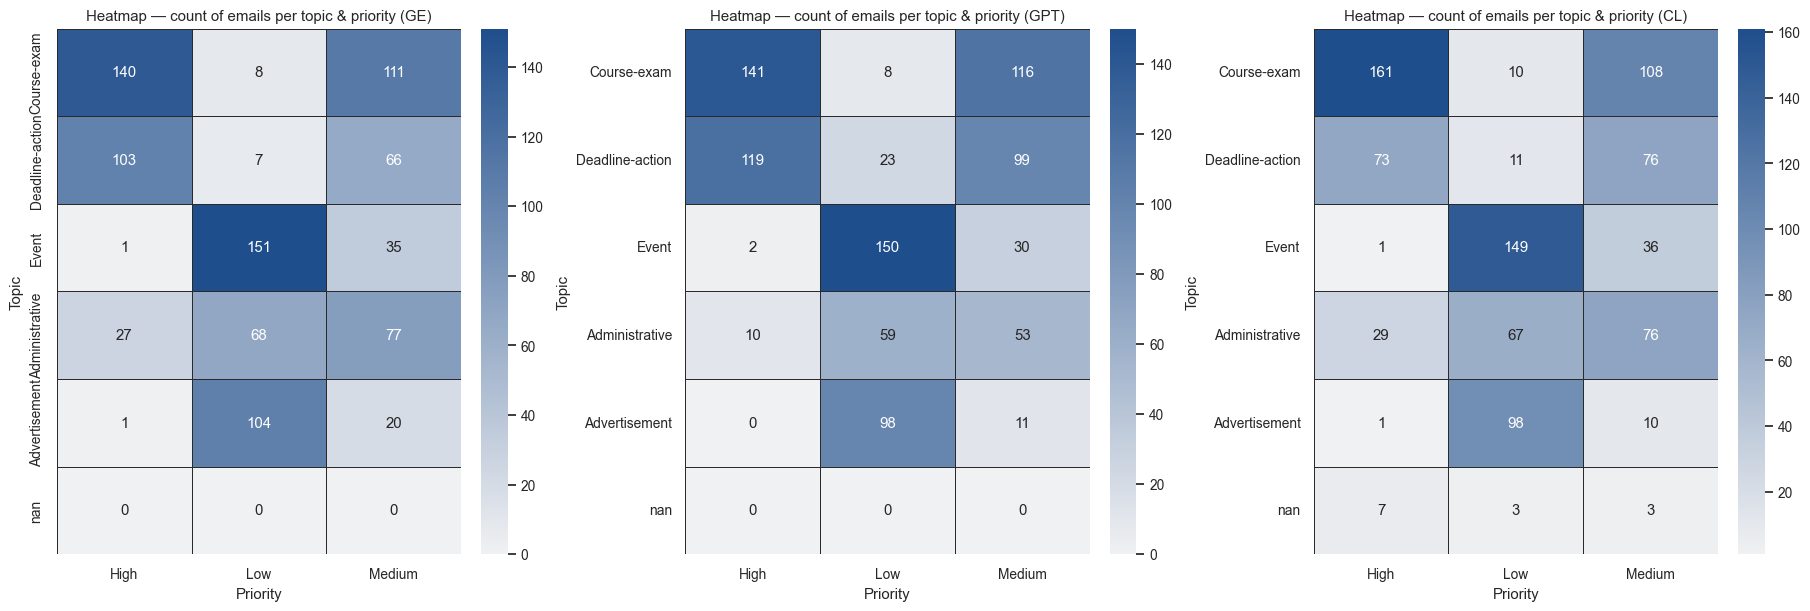

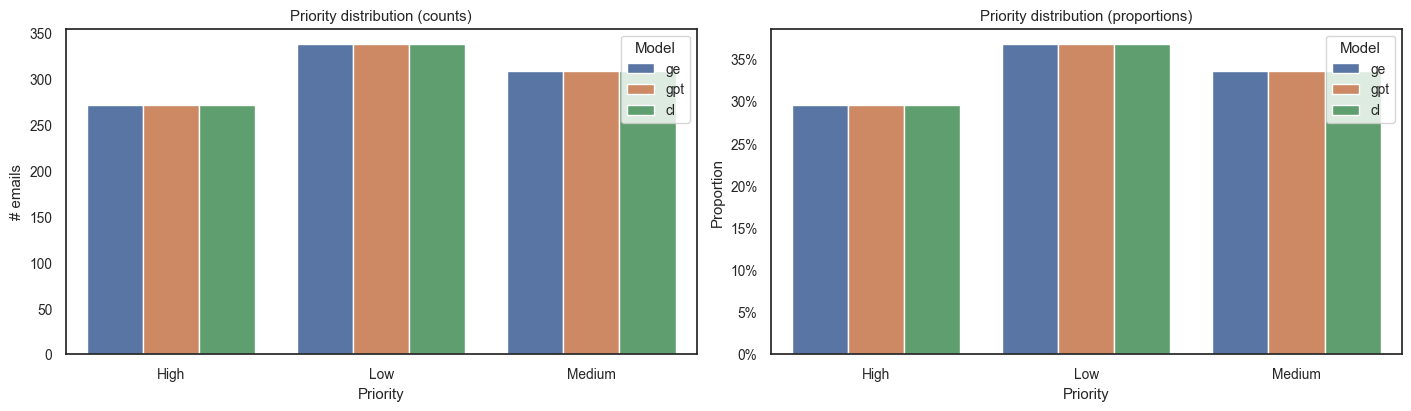

priority_label,High,Low,Medium
model,,,
ge,272,338,309
gpt,272,338,309
cl,272,338,309


Chi-square test (model × priority): chi2=0.000, dof=4, p=1


In [10]:
# === APPENDIX (optional, beyond report scope): re-run heatmaps / priority bars / chi-square on the cleaned 3-label data ===
df = pd.read_csv("../data/annotation/annotation_dataset_clean_3label.csv")

# --- Reshape to (model, topic_label, priority_label) ---
model_specs = {
    "ge": ("ge_topic_label", "ge_priority_label"),
    "gpt": ("gpt_topic_label", "gpt_priority_label"),
    "cl": ("cl_topic_label", "cl_priority_label"),
}

long_parts = []
for model, (topic_col, prio_col) in model_specs.items():
    part = df[["id", topic_col, prio_col]].copy()
    part = part.rename(columns={topic_col: "topic_label", prio_col: "priority_label"})
    part["model"] = model
    long_parts.append(part)

long_df = pd.concat(long_parts, ignore_index=True)

# Normalize label text a bit (in case of stray whitespace/casing)
long_df["topic_label"] = long_df["topic_label"].astype(str).str.strip()
long_df["priority_label"] = long_df["priority_label"].astype(str).str.strip()

# Orders (match your example: columns High, Low, Medium; we’ll still keep a stable categorical order)
priority_order = ["High", "Low", "Medium"]

# If some labels are missing, keep only what exists (prevents empty columns errors)
present_prios = [p for p in priority_order if p in set(long_df["priority_label"]) ]

# Choose a stable topic order by overall frequency (across all models)
topic_order = (
    long_df["topic_label"].value_counts()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# --- Heatmaps: count of emails per topic & priority, for each model ---

def plot_heatmap_for_model(model_name: str, ax: plt.Axes):
    sub = long_df[long_df["model"] == model_name]

    pivot = (
        sub.pivot_table(
            index="topic_label",
            columns="priority_label",
            values="id",
            aggfunc="count",
            fill_value=0,
        )
        .reindex(index=topic_order)
        .reindex(columns=present_prios)
    )

    # reindex can introduce NaNs for missing topics/priorities; fill then cast for fmt="d"
    pivot = pivot.fillna(0).astype(int)

    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap=sns.light_palette("#1f4e8c", as_cmap=True),
        linewidths=0.5,
        linecolor="#2a2a2a",
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Heatmap — count of emails per topic & priority ({model_name.upper()})")
    ax.set_xlabel("Priority")
    ax.set_ylabel("Topic")


sns.set_theme(style="white", font_scale=0.9)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, model in zip(axes, ["ge", "gpt", "cl"]):
    plot_heatmap_for_model(model, ax)
plt.show()

# --- Compare distribution of priority labels between CL, GPT, and GE ---

# Counts per model
prio_counts = (
    long_df.groupby(["model", "priority_label"]) ["id"].count().rename("count").reset_index()
)

# Ensure consistent ordering
prio_counts["priority_label"] = pd.Categorical(prio_counts["priority_label"], categories=present_prios, ordered=True)
prio_counts["model"] = pd.Categorical(prio_counts["model"], categories=["ge", "gpt", "cl"], ordered=True)
prio_counts = prio_counts.sort_values(["model", "priority_label"])

# Proportions per model
prio_totals = prio_counts.groupby("model")["count"].transform("sum")
prio_counts["prop"] = prio_counts["count"] / prio_totals

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

sns.barplot(
    data=prio_counts,
    x="priority_label",
    y="count",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("Priority distribution (counts)")
axes[0].set_xlabel("Priority")
axes[0].set_ylabel("# emails")

sns.barplot(
    data=prio_counts,
    x="priority_label",
    y="prop",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("Priority distribution (proportions)")
axes[1].set_xlabel("Priority")
axes[1].set_ylabel("Proportion")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0%}"))

for ax in axes:
    ax.legend(title="Model")

plt.show()

# Optional: simple statistical test (chi-square) on model × priority contingency
contingency = (
    long_df.pivot_table(
        index="model",
        columns="priority_label",
        values="id",
        aggfunc="count",
        fill_value=0,
    )
    .reindex(index=["ge", "gpt", "cl"])
    .reindex(columns=present_prios)
)

try:
    from scipy.stats import chi2_contingency

    chi2, p, dof, expected = chi2_contingency(contingency.values)
    display(contingency)
    print(f"Chi-square test (model × priority): chi2={chi2:.3f}, dof={dof}, p={p:.3g}")
except Exception as e:
    display(contingency)
    print("SciPy not available (or test failed). Showing contingency table only.")
    print(f"Details: {type(e).__name__}: {e}")
